# Align TNG Embeddings Across Redshifts

This notebook aligns MDS embeddings from TNG100 snapshots at different redshifts using optimal transport.

- Snapshot 99: z ≈ 0 (present day)
- Snapshot 51: z ≈ 0.95 (earlier universe)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import ot

## Load Embeddings

In [5]:
# Load z=0 embedding (snapshot 99)
data_z0 = np.load('tng100_embedding_0.npz')
embedding_z0 = data_z0['embedding']
original_index_z0 = data_z0['original_index']

print(f"z=0 embedding shape: {embedding_z0.shape}")
print(f"z=0 subhalo count: {len(original_index_z0)}")

z=0 embedding shape: (17611, 3)
z=0 subhalo count: 17611


In [6]:
# Load z=0.95 embedding (snapshot 51)
data_z1 = np.load('tng100_embedding_0.95.npz')
embedding_z1 = data_z1['embedding']
original_index_z1 = data_z1['original_index']

print(f"z=0.95 embedding shape: {embedding_z1.shape}")
print(f"z=0.95 subhalo count: {len(original_index_z1)}")

z=0.95 embedding shape: (15052, 3)
z=0.95 subhalo count: 15052


## Plot Embeddings Before Alignment

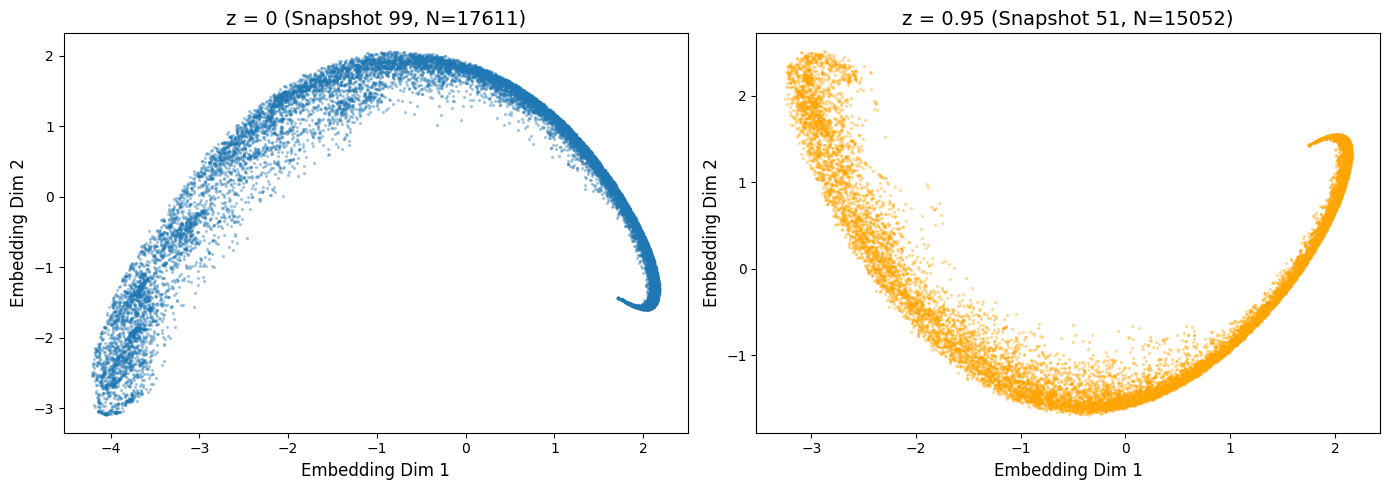

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# z=0 embedding
ax = axes[0]
ax.scatter(embedding_z0[:, 0], embedding_z0[:, 1], s=2, alpha=0.3)
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title(f'z = 0 (Snapshot 99, N={len(embedding_z0)})', fontsize=14)

# z=0.95 embedding
ax = axes[1]
ax.scatter(embedding_z1[:, 0], embedding_z1[:, 1], s=2, alpha=0.3, color='orange')
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title(f'z = 0.95 (Snapshot 51, N={len(embedding_z1)})', fontsize=14)

plt.tight_layout()
plt.show()

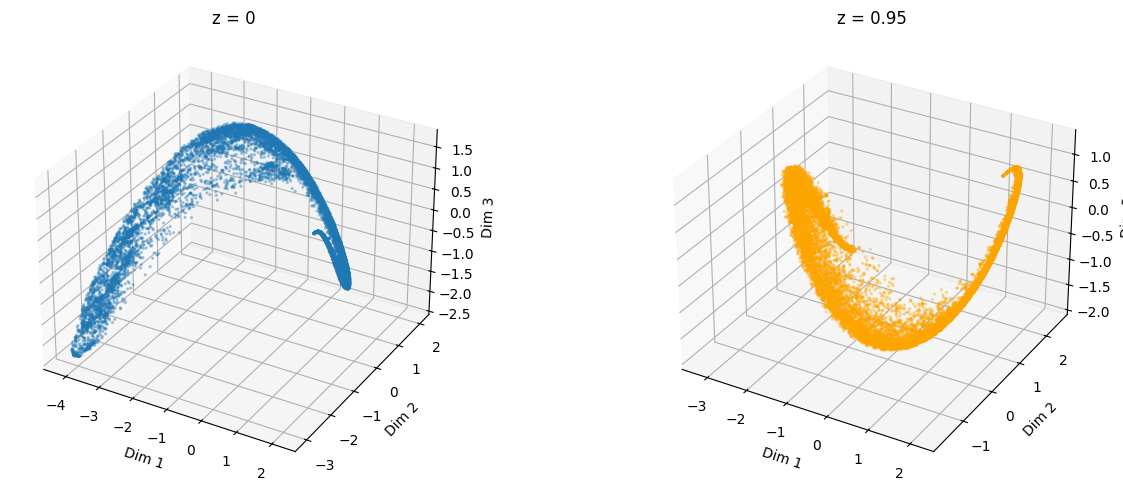

In [8]:
# 3D plot of embeddings
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(embedding_z0[:, 0], embedding_z0[:, 1], embedding_z0[:, 2], s=2, alpha=0.3)
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.set_zlabel('Dim 3')
ax1.set_title('z = 0')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_z1[:, 0], embedding_z1[:, 1], embedding_z1[:, 2], s=2, alpha=0.3, color='orange')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
ax2.set_title('z = 0.95')

plt.tight_layout()
plt.show()

## Overlay Embeddings (Before Alignment)

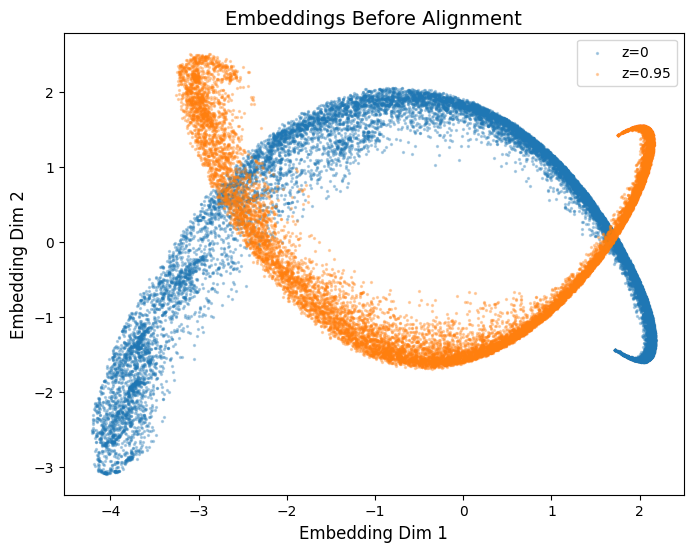

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(embedding_z0[:, 0], embedding_z0[:, 1], s=2, alpha=0.3, label='z=0')
plt.scatter(embedding_z1[:, 0], embedding_z1[:, 1], s=2, alpha=0.3, label='z=0.95')
plt.xlabel('Embedding Dim 1', fontsize=12)
plt.ylabel('Embedding Dim 2', fontsize=12)
plt.title('Embeddings Before Alignment', fontsize=14)
plt.legend()
plt.show()